## XML Parsing

In [ ]:
import xml.etree.ElementTree as ET
import re
import pandas as pd
from tqdm import tqdm

def clean_text(text):
    if not text:
        return ""
    text = re.sub(r"\{\{.*?\}\}", "", text, flags=re.DOTALL)
    text = re.sub(r"\[\[File:.*?\]\]", "", text)
    text = re.sub(r"<ref.*?>.*?</ref>", "", text, flags=re.DOTALL)
    text = re.sub(r"==.*?==", "", text)
    text = re.sub(r"\n{2,}", "\n", text)
    return text.strip()

def extract_first_paragraph(text):
    text = re.sub(r"\{\{[^{}]*\}\}", "", text)
    paragraphs = re.split(r"\n{1,}", text.strip())

    for p in paragraphs:
        if len(p.split()) >= 5 and not p.strip().startswith(("*", "|", "{{", "[[")):
            return p.strip()
    return ""

def clean_paragraph(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", "", text)
    text = re.sub(r"\{\{.*?\}\}", "", text, flags=re.DOTALL)
    text = re.sub(r"\[\[File:.*?\]\]", "", text)
    text = re.sub(r"<ref.*?>.*?</ref>", "", text, flags=re.DOTALL)
    text = re.sub(r"\|.*?=", "", text)
    text = re.sub(r"\[\[(?:[^\]|]*\|)?([^\]]+)\]\]", r"\1", text)
    text = re.sub(r"={2,}.*?={2,}", "", text)
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"'''?|\"\"\"?", "", text)
    return text.strip()

def is_valid_paragraph(text):
    if not isinstance(text, str) or len(text.strip()) < 20:
        return False
    return not re.match(r"^(<!--|\||{|#|File:|Module:|template:|category:)", text.strip(), re.IGNORECASE)

def is_valid_content(text):
    if not isinstance(text, str) or len(text.strip()) < 20:
        return False
    if re.fullmatch(r"[\d\W\s]+", text): return False
    if re.search(r"(template:|module:|file:|#redirect|\{\{|\|\||==)", text, re.IGNORECASE): return False
    return True

def filter_invalid_titles(df):
    invalid_prefixes = (
        "template:", "wikipedia:", "module:", "category:", 
        "file:", "help:", "portal:", "draft:", "mediawiki:"
    )
    return df[~df["title"].str.lower().str.startswith(invalid_prefixes)].copy()

# Simple Wikipedia parser
def parse_simplewiki(xml_file):
    data = []
    context = ET.iterparse(xml_file, events=("start", "end"))
    _, root = next(context)

    for event, elem in tqdm(context, desc="Parsing SimpleWiki"):
        if event == "end" and elem.tag.endswith("page"):
            title_elem = elem.find(".//{http://www.mediawiki.org/xml/export-0.11/}title")
            text_elem = elem.find(".//{http://www.mediawiki.org/xml/export-0.11/}text")

            if title_elem is None or text_elem is None or text_elem.text is None:
                continue

            title = title_elem.text.strip().lower()
            raw_text = clean_text(text_elem.text)
            first_paragraph = extract_first_paragraph(raw_text)

            if first_paragraph:
                data.append({
                    "title": title,
                    "simple_first_paragraph": first_paragraph
                })

            elem.clear()
            root.clear()

    return pd.DataFrame(data)

# English Wikipedia parser(including categories)
def extract_enwiki_paragraphs_with_categories(xml_file, matched_titles):
    extracted = []
    context = ET.iterparse(xml_file, events=("start", "end"))
    _, root = next(context)

    for event, elem in tqdm(context, desc="Parsing English Wikipedia"):
        if event == "end" and elem.tag.endswith("page"):
            title_elem = elem.find(".//{http://www.mediawiki.org/xml/export-0.11/}title")
            text_elem = elem.find(".//{http://www.mediawiki.org/xml/export-0.11/}text")

            if title_elem is not None and text_elem is not None:
                title = title_elem.text.strip().lower()
                if title in matched_titles:
                    text = text_elem.text or ""
                    cleaned = clean_text(text)
                    first_paragraph = extract_first_paragraph(cleaned)
                    categories = re.findall(r"\[\[category:(.*?)\]\]", text, re.IGNORECASE)
                    categories = [cat.strip() for cat in categories if cat.strip()]

                    if first_paragraph:
                        extracted.append({
                            "title": title,
                            "en_first_paragraph": first_paragraph,
                            "en_categories": categories
                        })

            elem.clear()
            root.clear()

    return pd.DataFrame(extracted)

# Page SQL parser
def parse_page_sql(file_path, limit=None):
    rows = []
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    for line in tqdm(lines, desc="Parsing page.sql"):
        if line.startswith("INSERT INTO") and "VALUES" in line:
            matches = re.findall(r"\((\d+),(\d+),'([^']+)'", line)
            for m in matches:
                page_id = int(m[0])
                namespace = int(m[1])
                title = m[2].replace("_", " ").strip()
                if namespace == 0:
                    rows.append((page_id, title))
                if limit and len(rows) >= limit:
                    break
        if limit and len(rows) >= limit:
            break

    return pd.DataFrame(rows, columns=["page_id", "title"])

In [ ]:
df_simple = parse_simplewiki("simplewiki-20250301-pages-articles.xml")
df_en = extract_enwiki_paragraphs_with_categories("enwiki-20250301-pages-articles.xml", matched_titles=set(df_simple["title"]))
df_page_ids = parse_page_sql("enwiki-20250301-page.sql")

df_simple.to_csv("simplewiki_parsed.csv", index=False)
df_en.to_csv("enwiki_parsed.csv", index=False)
df_page_ids.to_csv("page_parsed.csv", index=False)

## Title matching and Data Merging

In [ ]:
import pandas as pd
import requests
from tqdm import tqdm
import time

# Load CSVs
df_simple = pd.read_csv("simplewiki_parsed.csv")
df_en = pd.read_csv("enwiki_parsed.csv")
df_page_ids = pd.read_csv("page_parsed.csv")

# Lowercase titles for matching
df_simple["title_lower"] = df_simple["title"].str.lower()
df_en["title_lower"] = df_en["title"].str.lower()
#matched_titles = set(df_simple["title_lower"]).intersection(set(df_en["title_lower"]))
df_page_ids["title_lower"] = df_page_ids["title"].str.lower()

{'caldecott medal',
 'pseudis platensis',
 'violation',
 'wikileaks',
 'zee bangla',
 'hardeep singh nijjar',
 'havre, montana',
 'uss abraham lincoln (cvn-72)',
 'ballersdorf',
 'jes (musician)',
 'papal conclave',
 'joppa, illinois',
 'la faute-sur-mer',
 'capital punishment in north korea',
 'doug barnard jr.',
 'eastern green mamba',
 'bathing',
 'cyrtodactylus phongnhakebangensis',
 'public health',
 'world skate',
 'stay with me (sam smith song)',
 'atlanta hawks',
 'anneliese seonbuchner',
 'rachael harris',
 'max weber',
 'hastings, new zealand',
 'rattenberg, bavaria',
 'impeachment',
 'beaumes-de-venise',
 'module:location map/data/canton of jura/doc',
 'sommesous',
 'wyandotte, oklahoma',
 'sherman, texas',
 'gianni celati',
 'mack sennett',
 'jigme khesar namgyel wangchuck',
 'nash, north dakota',
 'united we stand, divided we fall',
 'template:unblock/doc',
 'olgiate comasco',
 'album (disambiguation)',
 'florencia, caquetá',
 'ingegerd troedsson',
 'unfaithful (song)',
 '

In [ ]:
# Merge simple and enwiki
df_merged = pd.merge(df_simple, df_en, on="title_lower", suffixes=("_simple", "_en"))
df_merged = df_merged.rename(columns={"title_simple": "title"})
df_merged = df_merged.drop(columns=["title_en", "title_lower"])

# Add page_id
df_merged["title_lower"] = df_merged["title"].str.lower()
df_merged = pd.merge(df_merged, df_page_ids[["page_id", "title_lower"]], on="title_lower", how="left")
df_merged = df_merged[df_merged["page_id"].notna()].copy()
df_merged["page_id"] = df_merged["page_id"].astype(int)

#df_merged.to_csv("ForRevidParallel.csv", index=False) # 344,041 raws

## Page ID and Revision ID Retrieval

In [ ]:
import pandas as pd
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import os

# Settings
INPUT_CSV = "ForRevidParallel.csv" # 344,041 raws 
OUTPUT_CSV = "df_revid_parallel.csv" # 344,041 raws 
NUM_WORKERS = 10
BATCH_SIZE = 200

# Load file
df = pd.read_csv(INPUT_CSV)
if "revid" not in df.columns:
    df["revid"] = None

df_pending = df[df["revid"].isna()].copy()
print(f"Pending rows: {len(df_pending)}")

# Fetch revid function
def fetch_revid(row):
    page_id = int(row["page_id"])
    for attempt in range(3):
        try:
            url = f"https://en.wikipedia.org/w/api.php?action=query&format=json&pageids={page_id}&prop=revisions&rvprop=ids"
            response = requests.get(url, timeout=5)
            if response.status_code == 200:
                data = response.json()
                revid = data["query"]["pages"][str(page_id)]["revisions"][0]["revid"]
                return {**row, "revid": revid}
        except Exception as e:
            time.sleep(1)
    return {**row, "revid": None}

# Parallel execution + periodic saving
results = []
with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = [executor.submit(fetch_revid, row) for row in df_pending.to_dict("records")]

    for i, future in enumerate(tqdm(as_completed(futures), total=len(futures), desc="Fetching revids")):
        results.append(future.result())

        if (i + 1) % BATCH_SIZE == 0 or (i + 1) == len(futures):
            df_batch = pd.DataFrame(results)
            mode = "w" if not os.path.exists(OUTPUT_CSV) else "a"
            header = not os.path.exists(OUTPUT_CSV)
            df_batch.to_csv(OUTPUT_CSV, mode=mode, header=header, index=False)
            results.clear()
print(f"revid collection complete! Saved to {OUTPUT_CSV}")

## ORES Topic Prediction and Main Topic Assignment

In [ ]:
import pandas as pd
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import os
import time

INPUT_CSV = "df_revid_parallel.csv"
OUTPUT_CSV = "df_ores_topics_parallel.csv" # 396,513 raws
NUM_WORKERS = 10
BATCH_SIZE = 200

# Load file
df = pd.read_csv(INPUT_CSV)
if "ores_topics" not in df.columns:
    df["ores_topics"] = None

# Pending rows for ORES prediction
df_pending = df[df["ores_topics"].isna() & df["revid"].notna()].copy()
print(f" Pending rows for ORES prediction: {len(df_pending)}")

# ORES fetch function
def fetch_ores_topic(row):
    revid = int(row["revid"])
    for attempt in range(3):
        try:
            url = f"https://ores.wikimedia.org/v3/scores/enwiki/{revid}/articletopic"
            response = requests.get(url, timeout=5)
            if response.status_code == 200:
                data = response.json()
                prediction = data["enwiki"]["scores"][str(revid)]["articletopic"]["score"]["prediction"]
                return {**row, "ores_topics": prediction}
        except Exception as e:
            time.sleep(1)  # wait before retry
    return {**row, "ores_topics": []} 

# Parallel execution + periodic saving
results = []
with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = [executor.submit(fetch_ores_topic, row) for row in df_pending.to_dict("records")]

    for i, future in enumerate(tqdm(as_completed(futures), total=len(futures), desc="Fetching ORES topics")):
        results.append(future.result())

        # Save in batches
        if (i + 1) % BATCH_SIZE == 0 or (i + 1) == len(futures):
            df_batch = pd.DataFrame(results)
            mode = "w" if not os.path.exists(OUTPUT_CSV) else "a"
            header = not os.path.exists(OUTPUT_CSV)
            df_batch.to_csv(OUTPUT_CSV, mode=mode, header=header, index=False)
            results.clear()

print(f" ORES topic prediction complete! Saved to {OUTPUT_CSV}")

In [ ]:
df_ores = pd.read_csv("df_ores_topics_parallel.csv")

df_ores_clean = df_ores.drop_duplicates(subset=["title", "revid"])
df_ores_clean.to_csv("df_ores_topics_deduplicated.csv", index=False)
print("Cleaned ORES topics saved! Final row count:", len(df_ores_clean))

# Calculate success rate for ores_topics
num_total = len(df_ores_clean)
num_with_topics = df_ores_clean["ores_topics"].apply(lambda x: len(eval(x)) > 0).sum()

print(f"ORES topics successfully assigned: {num_with_topics} / {num_total} ({(num_with_topics / num_total) * 100:.2f}%)")

## Before midterm - with top 15 frequent topic sampling

In [ ]:
import pandas as pd
from collections import Counter

# load data
df_ores_clean = pd.read_csv("df_ores_topics_deduplicated.csv")

# ORES topics list parsing
def parse_topics(topics):
    if isinstance(topics, str):
        return eval(topics)
    return topics

df_ores_clean["ores_topics"] = df_ores_clean["ores_topics"].apply(parse_topics)

# Top 15 topics 
all_topics = [topic for topics in df_ores_clean["ores_topics"] for topic in topics]
top_15_topics = [topic for topic, _ in Counter(all_topics).most_common(15)]

# Top 15 rank mapping
rank_map = {topic: rank for rank, topic in enumerate(top_15_topics)}

# Choose main_topic (if multiple, choose the one with highest rank in Top 15)
def filter_main_topics(topics):
    main_topics = [t for t in topics if t in top_15_topics]
    if len(main_topics) > 0:
        # 순위가 가장 높은 것 선택
        main_topics.sort(key=lambda x: rank_map[x])
        return main_topics[0]
    return None

df_ores_clean["main_topic"] = df_ores_clean["ores_topics"].apply(filter_main_topics)

# Filter rows with main_topic
df_ores_top15 = df_ores_clean[df_ores_clean["main_topic"].notnull()]

In [ ]:
import re

def clean_paragraph(text):
    if not isinstance(text, str):
        return ""
    
    # HTML tag removal
    text = re.sub(r"<.*?>", "", text)
    
    # Wiki Markup removal
    text = re.sub(r"\[\[.*?\|(.+?)\]\]", r"\1", text)  
    text = re.sub(r"\[\[(.+?)\]\]", r"\1", text)       
    text = re.sub(r"\{\{.*?\}\}", "", text, flags=re.DOTALL)
    text = re.sub(r"={2,}.*?={2,}", "", text) 
    text = re.sub(r"#REDIRECT", "", text, flags=re.IGNORECASE)
    text = re.sub(r"Location", "", text, flags=re.IGNORECASE)
    text = re.sub(r"Coordinates", "", text, flags=re.IGNORECASE)
    text = re.sub(r"<!--.*?-->", "", text, flags=re.DOTALL)
    text = re.sub(r"[\{\}\[\]\|\-\*·•→]+", "", text)
    text = re.sub(r"[0-9]+\s*[\.\)]\s*", "", text) 
    text = re.sub(r"\s+", " ", text)

    # Filter out very short paragraphs
    if len(text.split()) < 5:
        return ""

    text = text.strip()
    
    # Minimum length requirement
    if len(text) < 50:
        return ""
    
    return text

# Preprocessing 
df_ores_top15["simple_first_paragraph"] = df_ores_top15["simple_first_paragraph"].apply(clean_paragraph)
df_ores_top15["en_first_paragraph"] = df_ores_top15["en_first_paragraph"].apply(clean_paragraph)

# After preprocessing, remove rows where either paragraph is empty
df_ores_top15 = df_ores_top15[
    (df_ores_top15["simple_first_paragraph"] != "") & 
    (df_ores_top15["en_first_paragraph"] != "")
]
print(f"After preprocessing, total rows: {len(df_ores_top15)}")

In [ ]:
# main topic distribution
topic_counts = df_ores_top15["main_topic"].value_counts(normalize=True)
sampling_weights = {topic: int(10000 * freq) for topic, freq in topic_counts.items()}

# Weighted Sampling 
sampled_dfs = []
for topic, size in sampling_weights.items():
    subset = df_ores_top15[df_ores_top15["main_topic"] == topic]
    if len(subset) >= size:
        sampled_dfs.append(subset.sample(n=size, replace=False))
    else:
        sampled_dfs.append(subset)

# If it is not 10,000, add more samples from top 15 topics in order
current_size = sum(len(df) for df in sampled_dfs)
if current_size < 10000:
    remaining_size = 10000 - current_size
    print(f"Remaining samples needed: {remaining_size}")
    
    # Top 15 순서대로 부족한 개수만큼 추가
    for topic in topic_counts.index:
        subset = df_ores_top15[df_ores_top15["main_topic"] == topic]
        remaining_subset = subset[~subset.index.isin(pd.concat(sampled_dfs).index)]
        if not remaining_subset.empty:
            needed = min(remaining_size, len(remaining_subset))
            sampled_dfs.append(remaining_subset.head(needed))
            remaining_size -= needed
        if remaining_size <= 0:
            break

# Finally concatenate and shuffle to get exactly 10,000 samples
final_sampled_df = pd.concat(sampled_dfs).sample(n=10000, replace=False)
final_sampled_df.to_csv("preprocessed_weighted_sampled_ores_topics_final.csv", index=False)

## LLM Generation

In [ ]:
def create_prompt(en_paragraph, simple_paragraph):
    prompt = f"""
    You are a highly capable language model that specializes in semantic analysis and information retention between different versions of texts.

    **Context**:
    1. English Wikipedia:
    {en_paragraph}

    2. Simple English Wikipedia:
    {simple_paragraph}

    **Task**:
    Analyze the two paragraphs and perform the following tasks:
    1. Identify and list the key pieces of information that are retained in the Simple English version.
    2. Identify and list the key pieces of information that are lost in the Simple English version.
    3. Calculate the Semantic Retention Score as a percentage.

    **Output Format (JSON)**:
    {{
        "Semantic Retention Score": "XX%",
        "Retained List": [
            "Fact 1",
            "Fact 2",
            ...
        ],
        "Lost List": [
            "Fact 1",
            "Fact 2",
            ...
        ]
    }}
    """
    return prompt

In [ ]:
import ollama
import pandas as pd
from tqdm import tqdm
import logging
import os

# Load the full dataset
data = pd.read_csv("preprocessed_weighted_sampled_ores_topics_final.csv")

# Setup logging
logging.basicConfig(
    filename='processed.log',
    level=logging.INFO,
    format='%(asctime)s - %(message)s'
)

# Check existing file, if not create one
if not os.path.exists("llama_generation_results.csv"):
    pd.DataFrame(columns=["title", "main_topic", "llm_response"]).to_csv("llama_generation_results.csv", index=False)

# Load already processed titles
if os.path.exists('processed.log'):
    with open('processed.log', 'r') as f:
        processed_titles = {line.strip() for line in f.readlines()}
else:
    processed_titles = set()

# Progress bar with tqdm

print("Starting LLaMA 3 Inference...")
for index, row in tqdm(data.iterrows(), total=len(data), desc="Processing"):
    if row['title'] in processed_titles:
        continue
    
    en_paragraph = row['en_first_paragraph']
    simple_paragraph = row['simple_first_paragraph']
    
    # Generate the prompt
    prompt = create_prompt(en_paragraph, simple_paragraph)
    
    try:
        # Execute the model (LLaMA 3)
        response = ollama.generate(model="llama3:latest", prompt=prompt)
        
        # Store the result
        result = {
            "title": row['title'],
            "main_topic": row['main_topic'],
            "llm_response": response
        }
        
        # Append to CSV
        pd.DataFrame([result]).to_csv("llama_generation_results.csv", mode='a', header=False, index=False)
        
        # Log the processed title
        with open('processed.log', 'a') as log_file:
            log_file.write(f"{row['title']}\n")
        
        print(f"Successfully processed: {row['title']}")

    except Exception as e:
        logging.error(f"Failed to process {row['title']}: {str(e)}")
        continue

print("\nLLaMA 3 inference completed successfully! Results are saved to 'llama_generation_results.csv'.")

In [ ]:
import ollama
import pandas as pd
from tqdm import tqdm
import logging
import os

MODEL_NAME = "gemma:latest"
INPUT_CSV = "preprocessed_weighted_sampled_ores_topics_final.csv"
OUTPUT_CSV = "gemma_generation_results.csv"
LOG_FILE = "gemma_processed.log"

# Load dataset
data = pd.read_csv(INPUT_CSV)

# Setup logging
logging.basicConfig(
    filename='gemma_errors.log',
    level=logging.ERROR,
    format='%(asctime)s - %(message)s'
)

# Prepare output file
if not os.path.exists(OUTPUT_CSV):
    pd.DataFrame(columns=["title", "main_topic", "llm_response"]).to_csv(OUTPUT_CSV, index=False)

# Load already processed titles
if os.path.exists(LOG_FILE):
    with open(LOG_FILE, 'r') as f:
        processed_titles = {line.strip() for line in f.readlines()}
else:
    processed_titles = set()

# Inference loop
print("Starting inference with Phi model...")
for _, row in tqdm(data.iterrows(), total=len(data), desc="Processing"):
    title = row['title']
    if title in processed_titles:
        continue

    prompt = create_prompt(row['en_first_paragraph'], row['simple_first_paragraph'])

    try:
        response = ollama.generate(model=MODEL_NAME, prompt=prompt)
        generated = response['response'] if isinstance(response, dict) else response  # safeguard

        # Save result
        pd.DataFrame([{
            "title": title,
            "main_topic": row['main_topic'],
            "llm_response": generated
        }]).to_csv(OUTPUT_CSV, mode='a', header=False, index=False)

        # Log progress
        with open(LOG_FILE, 'a') as logf:
            logf.write(f"{title}\n")

        print(f"{title} processed")

    except Exception as e:
        logging.error(f"{title} - {str(e)}")
        print(f"{title} failed: {str(e)}")
        continue

print("All inference with gemma model completed!")

In [ ]:
import ollama
import pandas as pd
from tqdm import tqdm
import logging
import os

MODEL_NAME = "mistral:latest"
INPUT_CSV = "preprocessed_weighted_sampled_ores_topics_final.csv"
OUTPUT_CSV = "mistral_generation_results.csv"
LOG_FILE = "mistral_processed.log"

# Load dataset
data = pd.read_csv(INPUT_CSV)

# Setup logging
logging.basicConfig(
    filename='mistral_errors.log',
    level=logging.ERROR,
    format='%(asctime)s - %(message)s'
)

# Prepare output file
if not os.path.exists(OUTPUT_CSV):
    pd.DataFrame(columns=["title", "main_topic", "llm_response"]).to_csv(OUTPUT_CSV, index=False)

# Load already processed titles
if os.path.exists(LOG_FILE):
    with open(LOG_FILE, 'r') as f:
        processed_titles = {line.strip() for line in f.readlines()}
else:
    processed_titles = set()

# Inference loop
print("Starting inference with Mistral model...")
for _, row in tqdm(data.iterrows(), total=len(data), desc="Processing"):
    title = row['title']
    if title in processed_titles:
        continue

    prompt = create_prompt(row['en_first_paragraph'], row['simple_first_paragraph'])

    try:
        response = ollama.generate(model=MODEL_NAME, prompt=prompt)
        generated = response['response'] if isinstance(response, dict) else response  # safeguard

        # Save result
        pd.DataFrame([{
            "title": title,
            "main_topic": row['main_topic'],
            "llm_response": generated
        }]).to_csv(OUTPUT_CSV, mode='a', header=False, index=False)

        # Log progress
        with open(LOG_FILE, 'a') as logf:
            logf.write(f"{title}\n")

        print(f"{title} processed")

    except Exception as e:
        logging.error(f"{title} - {str(e)}")
        print(f"{title} failed: {str(e)}")
        continue

print("All inference with mistral model completed!")

In [ ]:
import ollama
import pandas as pd
from tqdm import tqdm
import logging
import os

MODEL_NAME = "gemma:latest"
INPUT_CSV = "preprocessed_weighted_sampled_ores_topics_final.csv"
OUTPUT_CSV = "gemma_generation_results.csv"
LOG_FILE = "gemma_processed.log"

# Load dataset
data = pd.read_csv(INPUT_CSV)

# Setup logging
logging.basicConfig(
    filename='gemma_errors.log',
    level=logging.ERROR,
    format='%(asctime)s - %(message)s'
)

# Prepare output file
if not os.path.exists(OUTPUT_CSV):
    pd.DataFrame(columns=["title", "main_topic", "llm_response"]).to_csv(OUTPUT_CSV, index=False)

# Load already processed titles
if os.path.exists(LOG_FILE):
    with open(LOG_FILE, 'r') as f:
        processed_titles = {line.strip() for line in f.readlines()}
else:
    processed_titles = set()

# Inference loop
print("Starting inference with Gemma model...")
for _, row in tqdm(data.iterrows(), total=len(data), desc="Processing"):
    title = row['title']
    if title in processed_titles:
        continue

    prompt = create_prompt(row['en_first_paragraph'], row['simple_first_paragraph'])

    try:
        response = ollama.generate(model=MODEL_NAME, prompt=prompt)
        generated = response['response'] if isinstance(response, dict) else response  # safeguard

        # Save result
        pd.DataFrame([{
            "title": title,
            "main_topic": row['main_topic'],
            "llm_response": generated
        }]).to_csv(OUTPUT_CSV, mode='a', header=False, index=False)

        # Log progress
        with open(LOG_FILE, 'a') as logf:
            logf.write(f"{title}\n")

        print(f"{title} processed")

    except Exception as e:
        logging.error(f"{title} - {str(e)}")
        print(f"{title} failed: {str(e)}")
        continue

print("All inference with gemma model completed!")

## Parsing Function

In [ ]:
import re
import ast
import json
import html
import pandas as pd
    
def parse_llama_response(response_text):
    if pd.notna(response_text):
        try:
            # Search for full JSON block
            match = re.search(r"(\{[\s\S]+?\})", response_text)

            if match:
                extracted_json = match.group(1)
                print("[INFO] JSON block found")

                # Preprocess extracted JSON
                extracted_json = extracted_json.replace("\\'", "'")
                extracted_json = extracted_json.replace('\\"', '"')
                extracted_json = extracted_json.replace("\\n", " ")
                extracted_json = extracted_json.replace("&nbsp;", " ")
                extracted_json = re.sub(r'\\u00[0-9a-fA-F]{2}', '', extracted_json)
                extracted_json = re.sub(r'\\(?!["\\/bfnrtu])', '', extracted_json)
                extracted_json = re.sub(r",\s*([\]\}])", r"\1", extracted_json)  # Remove trailing commas
                extracted_json = re.sub(r"//.*", "", extracted_json)  # Remove inline comments

                # Fix: Sample 1 – Add closing brace if missing
                if extracted_json.count("{") > extracted_json.count("}"):
                    extracted_json += "}"

                # Attempt JSON parsing
                try:
                    parsed_response = json.loads(extracted_json)
                    print("[INFO] JSON parsing successful")

                    score_raw = parsed_response.get('Semantic Retention Score', None)
                    if isinstance(score_raw, str) and "%" in score_raw:
                        score = float(score_raw.replace("%", "").strip())
                    elif isinstance(score_raw, (float, int)):
                        score = float(score_raw)
                    else:
                        score = None

                    retained = parsed_response.get("Retained List", [])
                    lost = parsed_response.get("Lost List", [])

                    retained = retained if isinstance(retained, list) else []
                    lost = lost if isinstance(lost, list) else []

                    return score, retained, lost

                except json.JSONDecodeError as e:
                    print("[WARN] JSON decoding failed → fallback to regex-based extraction")
                    # Fallback for formats like Sample 3 or 5
                    score_match = re.search(r'"Semantic Retention Score"\s*:\s*"?(?P<score>\d+\.?\d*)%?"?', extracted_json)
                    retained_match = re.search(r'"Retained List"\s*:\s*\[(?P<retained>.*?)\]', extracted_json, re.DOTALL)
                    lost_match = re.search(r'"Lost List"\s*:\s*\[(?P<lost>.*?)\]', extracted_json, re.DOTALL)

                    if score_match:
                        score = float(score_match.group("score"))
                    else:
                        score = None

                    def split_items(raw_text):
                        return [line.strip(" '\n\t") for line in raw_text.splitlines() if line.strip()]

                    retained = split_items(retained_match.group("retained")) if retained_match else []
                    lost = split_items(lost_match.group("lost")) if lost_match else []

                    # Sample 4: Allow returning results even if only one list exists
                    if score is not None or retained or lost:
                        return score, retained, lost

                    return None, None, None

            else:
                print("[WARN] No JSON block found → fallback to structured text parsing")
                # Sample 2 or 5 – Extract score from plain-text formula
                score_match = re.search(r"Semantic Retention Score(?: Calculation)?:\s*\**\s*(\d+\.?\d*)%?", response_text)
                if not score_match:
                    score_match = re.search(r"Semantic Retention Score\s*=\s*.*?=\s*(\d+\.?\d*)%", response_text)
                score = float(score_match.group(1)) if score_match else None

                # Extract retained and lost lists from markdown-style text
                retained_list_match = re.search(r"\*\*Retained (Key Pieces of Information|List):\*\*\s*\n?\[([\s\S]+?)\]", response_text)
                lost_list_match = re.search(r"\*\*Lost (Key Pieces of Information|List):\*\*\s*\n?\[([\s\S]+?)\]", response_text)

                def split_items(raw_text):
                    return [x.strip(" '\n\t") for x in raw_text.split("\n") if x.strip()]

                retained_list = split_items(retained_list_match.group(2)) if retained_list_match else []
                lost_list = split_items(lost_list_match.group(2)) if lost_list_match else []

                if score is not None or retained_list or lost_list:
                    return score, retained_list, lost_list
                else:
                    return None, None, None

        except Exception as e:
            print(f"[ERROR] LLaMA - Unexpected error during parsing: {e}")
            return None, None, None

    return None, None, None
    
def parse_mistral_response(response_text):
    """
    Robust parser for Mistral model output: JSON blocks, markdown, or free-form text.
    """
    if pd.isna(response_text):
        return None, None, None

    try:
        response_text = response_text.strip()

        # Find and clean JSON blocks
        matches = re.findall(r"\{[\s\S]*?\}", response_text)

        if matches:
            for extracted_json in reversed(matches): 
                cleaned_json = cleanup_json(extracted_json)
                try:
                    score, retained, lost = extract_json_fields(cleaned_json)
                    if score is not None or retained or lost:
                        return score, retained if isinstance(retained, list) else [], lost if isinstance(lost, list) else []
                except Exception as e:
                    continue

        # Fallback: regex-based extraction from structured text
        score_match = re.search(r"Semantic Retention Score.*?:.*?(\d+\.?\d*)%?", response_text)
        retained_match = re.search(r"Retained List\s*:\s*\[(.*?)\]", response_text, re.DOTALL)
        lost_match = re.search(r"Lost List\s*:\s*\[(.*?)\]", response_text, re.DOTALL)

        def split_items(raw):
            try:
                return ast.literal_eval(f"[{raw}]")
            except:
                return [item.strip(" '\n\t") for item in raw.split(",") if item.strip()]

        score = float(score_match.group(1)) if score_match else None
        retained = split_items(retained_match.group(1)) if retained_match else []
        lost = split_items(lost_match.group(1)) if lost_match else []

        if score is not None or retained or lost:
            return score, retained, lost
        else:
            return None, None, None

    except Exception as e:
        print(f"[ERROR] Mistral parsing failed: {e}")
        return None, None, None


def parse_gemma_response(text):
    if pd.isna(text):
        return None, None, None

    try:
        # Step 1: response= part extraction
        match = re.search(r"response=(['\"])(.*)\1", text, re.DOTALL)
        if not match:
            return None, None, None

        response_raw = match.group(2)

        # Step 2: escape 
        try:
            response_clean = ast.literal_eval(f"'{response_raw}'")  
        except Exception:
            response_clean = html.unescape(response_raw)  # fallback

        # Step 3: json code block extraction
        json_match = re.search(r"```json\s*(\{.*?\})\s*```", response_clean, re.DOTALL)
        if not json_match:
            return None, None, None

        json_str = json_match.group(1)

        # Step 4: JSON parsing
        data = json.loads(json_str)

        # Step 5: Field extraction and cleaning
        score_raw = data.get("Semantic Retention Score", "").strip()
        score = float(score_raw.replace('%', '').strip()) if score_raw else None
        retained = data.get("Retained List", [])
        lost = data.get("Lost List", [])

        return score, retained, lost

    except Exception as e:
        print("Gemma parse error:", e)
        return None, None, None

## After midterm - Mapping Main Categories

In [ ]:
import pandas as pd

df = pd.read_csv("preprocessed_weighted_sampled_ores_topics_final.csv")

category_map = {
    # Culture
    'Culture.Biography.Biography*': 'Culture',
    'Culture.Media.Media*': 'Culture',
    'Culture.Sports': 'Culture',
    'Culture.Literature': 'Culture',
    'Culture.Media.Music': 'Culture',
    'Culture.Biography.Women': 'Culture',

    # Geography
    'Geography.Regions.Europe.Europe*': 'Geography',
    'Geography.Regions.Americas.North America': 'Geography',
    'Geography.Regions.Asia.Asia*': 'Geography',
    'Geography.Geographical': 'Geography',
    'Geography.Regions.Europe.Northern Europe': 'Geography',
    'Geography.Regions.Europe.Western Europe': 'Geography',
    'Geography.Regions.Asia.South Asia': 'Geography',

    # STEM
    'STEM.STEM*': 'STEM',

    # History and Society
    'History and Society.Politics and government': 'History and Society'
}

df["main_category"] = df["main_topic"].map(category_map)
df.to_csv("preprocessed_with_main_category.csv", index=False)
print("Saved as: preprocessed_with_main_category.csv")

## Final Dataset Construction

In [ ]:
import pandas as pd
import re
import json

# Load master and raw LLM outputs ---
master_df = pd.read_csv("preprocessed_with_main_category.csv")
llama_df = pd.read_csv("llama_generation_results.csv")
llama_rerun_df = pd.read_csv("llama_generation_outlier_rerun.csv")
mistral_df = pd.read_csv("mistral_generation_results.csv")
gemma_df = pd.read_csv("gemma_generation_results.csv")

# Update llama_df with rerun results (based on title) ---
llama_df = llama_df.set_index("title")
llama_rerun_df = llama_rerun_df.set_index("title")
llama_df.update(llama_rerun_df)
llama_df.reset_index(inplace=True)

# Define parsing helpers---

# [cleanup_json, extract_json_fields, parse_llama_response, parse_mistral_response, parse_gemma_response]

# Apply parsing ---
llama_df[["llama_score", "llama_retained", "llama_lost"]] = llama_df["llm_response"].apply(
    lambda x: pd.Series(parse_llama_response(str(x)))
)

mistral_df[["mistral_score", "mistral_retained", "mistral_lost"]] = mistral_df["llm_response"].apply(
    lambda x: pd.Series(parse_mistral_response(str(x)))
)

gemma_df[["gemma_score", "gemma_retained", "gemma_lost"]] = gemma_df["llm_response"].apply(
    lambda x: pd.Series(parse_gemma_response(str(x)))
)

# - Deduplicate before merging 
llama_df = llama_df.drop_duplicates(subset="title", keep="last")
mistral_df = mistral_df.drop_duplicates(subset="title", keep="last")
gemma_df = gemma_df.drop_duplicates(subset="title", keep="last")

# Merge everything into master 
merged_df = master_df.merge(llama_df[["title", "llama_score", "llama_retained", "llama_lost"]], on="title", how="left")
merged_df = merged_df.merge(mistral_df[["title", "mistral_score", "mistral_retained", "mistral_lost"]], on="title", how="left")
merged_df = merged_df.merge(gemma_df[["title", "gemma_score", "gemma_retained", "gemma_lost"]], on="title", how="left")

# Final check 
print(f"Total rows in final merged_df: {len(merged_df)}")
print(f"Duplicate titles: {merged_df.duplicated(subset='title').sum()}")  # should be 0

# merged_df.to_csv("merged_with_llm_scores.csv", index=False)

In [ ]:
import pandas as pd

df = pd.read_csv("merged_with_llm_scores.csv")

keep_columns = [
'title', 'simple_first_paragraph', 'en_first_paragraph', 
'main_category','main_topic', 'ores_topics', 
'llama_score', 'llama_retained', 'llama_lost', 
'mistral_score', 'mistral_retained', 'mistral_lost', 
'gemma_score', 'gemma_retained', 'gemma_lost', 
'page_id', 'revid'
]

df = df[keep_columns]

df.to_csv("final_dataset.csv", index=False)

# 50 Human Validation 

In [ ]:
import pandas as pd
import re

# Load dataset
df = pd.read_csv("final_dataset.csv")

# Normalize titles
def normalize_title(title):
    title = str(title).lower()
    title = re.sub(r"['\"”“‘’´`]", "", title)
    title = re.sub(r"\s+", " ", title)
    return title.strip()

df['title_normalized'] = df['title'].apply(normalize_title)

# Validated titles
validated_titles_raw = [
    "charlotte of belgium",
    "liz sheridan",
    "mercedario",
    "oscar hertwig",
    "stewart island kiwi",
    "jake gyllenhaal",
    "wissignicourt",
    "bureau of indian affairs",
    "holliday grainger"
]
validated_titles = [normalize_title(t) for t in validated_titles_raw]

# Separate validated and remaining
df['is_validated'] = df['title_normalized'].isin(validated_titles)
validated_df = df[df['is_validated']].copy()
remaining_df = df[~df['is_validated']].copy()

# Initialize
final_samples = []
used_titles = set(validated_df['title_normalized'])
final_df = pd.DataFrame()

# Category sampling limit
target_category_limit = {
    'Culture': 13,
    'Geography': 13,
    'STEM': 12,
    'History and Society': 12
}

# Step 1: Fill each category up to its target (with validated first)
for cat, max_allowed in target_category_limit.items():
    validated_cat = validated_df[validated_df['main_category'] == cat]
    n_validated = len(validated_cat)

    # How many more to sample
    n_needed = max(0, max_allowed - n_validated)

    pool = remaining_df[
        (remaining_df['main_category'] == cat) &
        (~remaining_df['title_normalized'].isin(used_titles))
    ]
    sampled = pool.sample(n=min(n_needed, len(pool)), random_state=42)

    # Update
    final_samples.extend([validated_cat, sampled])
    used_titles.update(sampled['title_normalized'])

# Combine to 48
final_48 = pd.concat(final_samples).drop_duplicates(subset='title_normalized').reset_index(drop=True)

# Step 2: Fill remaining (50 - len) respecting per-category caps
current_counts = final_48['main_category'].value_counts().to_dict()
missing = 50 - len(final_48)
extra_samples = []

priority_order = ['Culture', 'Geography', 'STEM', 'History and Society']
for cat in priority_order:
    if missing <= 0:
        break
    current_count = current_counts.get(cat, 0)
    allowed = target_category_limit[cat]
    room = allowed - current_count
    if room <= 0:
        continue

    pool = remaining_df[
        (remaining_df['main_category'] == cat) &
        (~remaining_df['title_normalized'].isin(used_titles))
    ]
    to_sample = min(missing, room, len(pool))
    if to_sample > 0:
        sample = pool.sample(n=to_sample, random_state=42)
        extra_samples.append(sample)
        used_titles.update(sample['title_normalized'])
        missing -= to_sample
        current_counts[cat] = current_counts.get(cat, 0) + to_sample

# Final dataset
final_df = pd.concat([final_48] + extra_samples).drop(columns=['title_normalized', 'is_validated']).reset_index(drop=True)

# Check
print("Final sample size:", len(final_df))
print("Final main_category distribution:")
print(final_df['main_category'].value_counts())

In [ ]:
# Save to Csv
final_df.to_csv("human_validation_final_50samples.csv", index=False)
# Save to Excel
final_df.to_excel("human_validation_final_50samples.xlsx", index=False, engine='openpyxl')

## Final Analysis

All figures included in the Final Analysis section were generated using the final dataset (final_dataset.csv). 
The figures are based exclusively on this dataset to ensure consistency with the final results presented in the thesis.

Please note that intermediate files created during the construction of the final dataset are not included in the GitHub repository, as they were only used for processing steps and are not necessary for reproducing the final analysis.

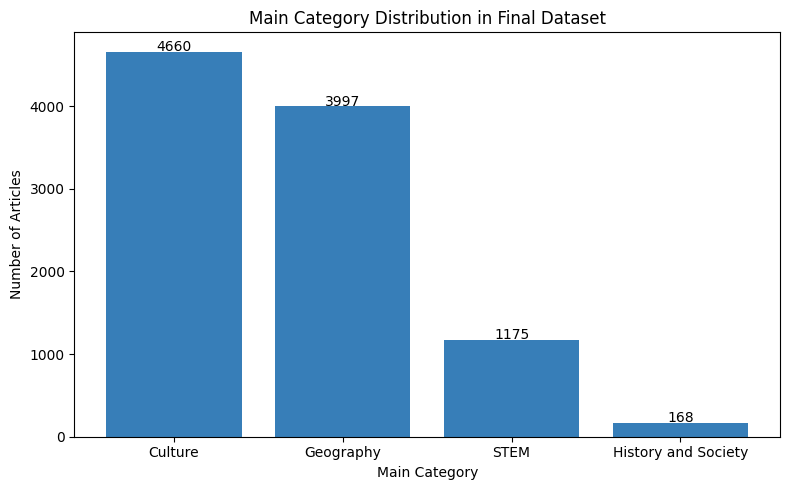

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("final_dataset.csv")

# Plot: Main Category Distribution
plt.figure(figsize=(8, 5))
category_counts = df["main_category"].value_counts()
bars = plt.bar(category_counts.index, category_counts.values, color="#377eb8")

# Label each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 10, f"{int(height)}", ha="center")

plt.title("Main Category Distribution in Final Dataset")
plt.xlabel("Main Category")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.show()

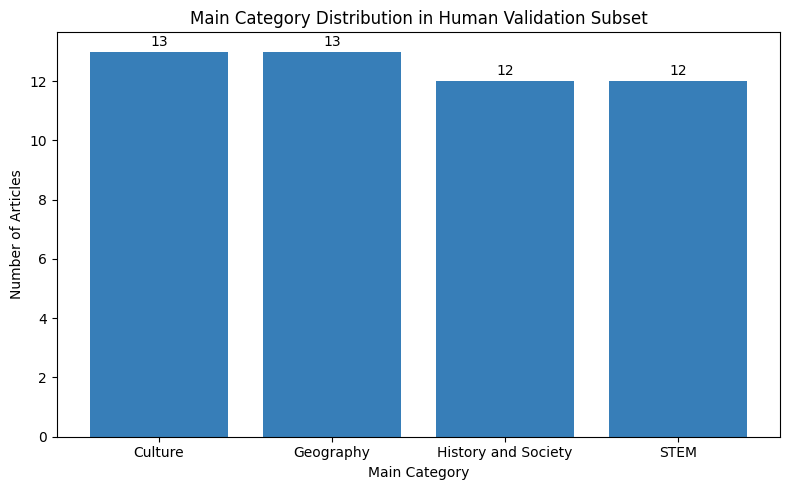

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("human_validation_final_50samples.csv")

category_counts = df['main_category'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(category_counts.index, category_counts.values, color="#377eb8")
plt.title("Main Category Distribution in Human Validation Subset")
plt.xlabel("Main Category")
plt.ylabel("Number of Articles")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1,
             f'{int(height)}', ha='center', va='bottom', color='black', fontsize=10)

plt.tight_layout()
plt.show()

=== Validity Summary ===
         N total  N valid (0-100)  N NA  N out-of-range
Model                                                  
LLaMA      10000             9796   202               2
Mistral    10000             9968    31               1
Gemma      10000             9873   127               0 

=== Overall Mean/Median (valid only) ===
         Mean (valid only)  Median (valid only)  N valid
Model                                                   
LLaMA               65.617                 67.0     9796
Mistral             66.652                 75.0     9968
Gemma               75.097                 80.0     9873 

=== Category Averages (valid only) ===
                     LLaMA  Mistral  Gemma
main_category                             
Culture              65.68    68.43  75.47
Geography            66.10    67.48  75.49
History and Society  63.67    59.96  72.43
STEM                 64.01    57.76  72.65 



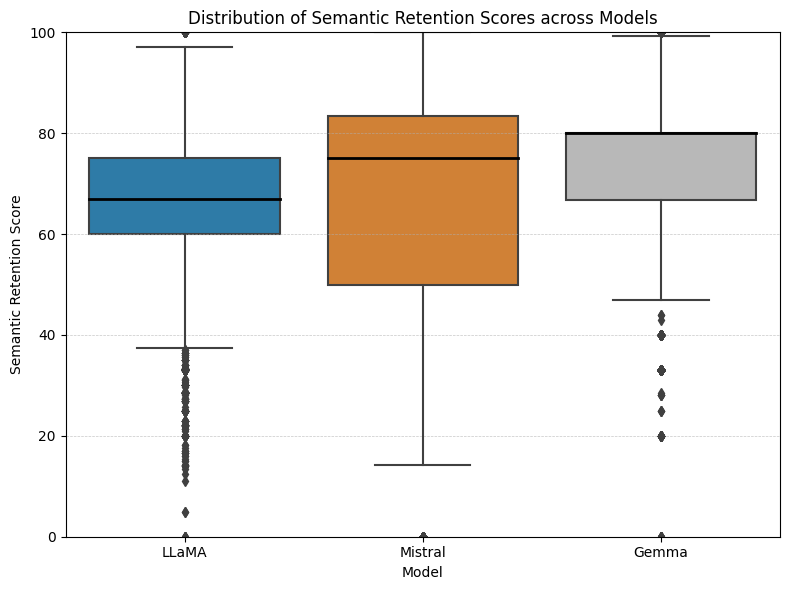

/var/folders/j5/tqm3_jyd1mz9mmb920s62hlm0000gn/T/ipykernel_29891/1214199269.py:118: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


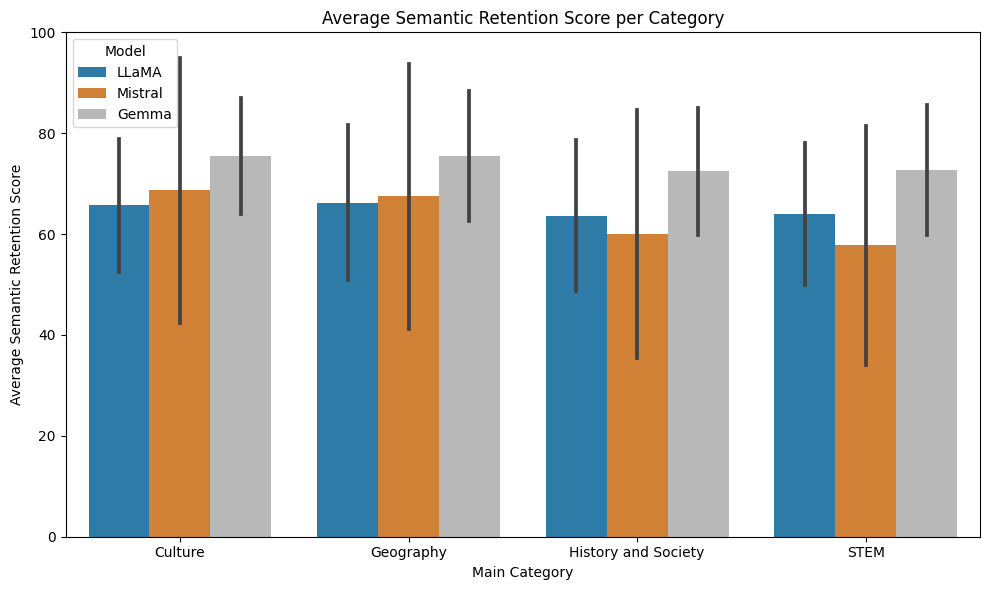

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

MODEL_COLS = {
    "LLaMA":  "llama_score",
    "Mistral":"mistral_score",
    "Gemma":  "gemma_score",
}
CATEGORY_ORDER = ["Culture", "Geography", "History and Society", "STEM"]

MODEL_COLORS = {
    "LLaMA": "#1a80bb",     # blue
    "Mistral": "#ea801c",   # orange
    "Gemma": "#b8b8b8"      # gray
}

df = pd.read_csv("final_dataset.csv")

for col in MODEL_COLS.values():
    df[col] = pd.to_numeric(df[col], errors="coerce")

if "main_category" in df.columns:
    df["main_category"] = pd.Categorical(df["main_category"],
                                         categories=CATEGORY_ORDER,
                                         ordered=True)

summary_rows = []
for model, col in MODEL_COLS.items():
    total = len(df)
    na_cnt = df[col].isna().sum()
    out_of_range = df[col].notna() & ((df[col] < 0) | (df[col] > 100))
    oor_cnt = int(out_of_range.sum())
    valid_mask = df[col].between(0, 100, inclusive="both")
    valid_cnt = int(valid_mask.sum())
    summary_rows.append({
        "Model": model,
        "N total": total,
        "N valid (0-100)": valid_cnt,
        "N NA": int(na_cnt),
        "N out-of-range": oor_cnt
    })
summary_df = pd.DataFrame(summary_rows).set_index("Model")
print("=== Validity Summary ===")
print(summary_df, "\n")

df_valid = df.copy()
for col in MODEL_COLS.values():
    mask_valid = df_valid[col].between(0, 100, inclusive="both")
    df_valid.loc[~mask_valid, col] = np.nan


stats_rows = []
for model, col in MODEL_COLS.items():
    s = df_valid[col].dropna()
    stats_rows.append({
        "Model": model,
        "Mean (valid only)": round(s.mean(), 3) if len(s) else np.nan,
        "Median (valid only)": round(s.median(), 3) if len(s) else np.nan,
        "N valid": int(s.size)
    })
stats_df = pd.DataFrame(stats_rows).set_index("Model")
print("=== Overall Mean/Median (valid only) ===")
print(stats_df, "\n")

if "main_category" in df_valid.columns:
    category_avg = df_valid.groupby("main_category")[list(MODEL_COLS.values())].mean()
    category_avg.columns = list(MODEL_COLS.keys())
    category_avg = category_avg.round(2)
    print("=== Category Averages (valid only) ===")
    print(category_avg, "\n")
else:
    print("No 'main_category' column found; skipping category averages.\n")

# ----------------------------
# Boxplot across models
# ----------------------------
model_scores = df[["llama_score", "mistral_score", "gemma_score"]].copy()
model_scores.columns = ["LLaMA", "Mistral", "Gemma"]
model_scores_long = model_scores.melt(var_name="Model", value_name="Score")

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=model_scores_long,
    x="Model",
    y="Score",
    palette=MODEL_COLORS,
    medianprops=dict(color="black", linewidth=2) 
)
plt.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
plt.ylabel("Semantic Retention Score")
plt.title("Distribution of Semantic Retention Scores across Models")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("AvgScoresCategory.png")
plt.show()

# ----------------------------
# Barplot across categories
# ----------------------------
df_long = pd.melt(
    df,
    id_vars=["main_category"],
    value_vars=["llama_score", "mistral_score", "gemma_score"],
    var_name="Model",
    value_name="Score"
)

df_long["Model"] = df_long["Model"].str.replace("_score", "", regex=False)
df_long["Model"] = df_long["Model"].map({
    "llama": "LLaMA",
    "mistral": "Mistral",
    "gemma": "Gemma"
})

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_long,
    x="main_category",
    y="Score",
    hue="Model",
    palette=MODEL_COLORS,
    ci="sd",
    order=CATEGORY_ORDER  
)
plt.ylabel("Average Semantic Retention Score")
plt.xlabel("Main Category")
plt.title("Average Semantic Retention Score per Category")
plt.ylim(0, 100)
plt.legend(title="Model")
plt.tight_layout()
plt.savefig("AvgScoresBoxplots.png")
plt.show()


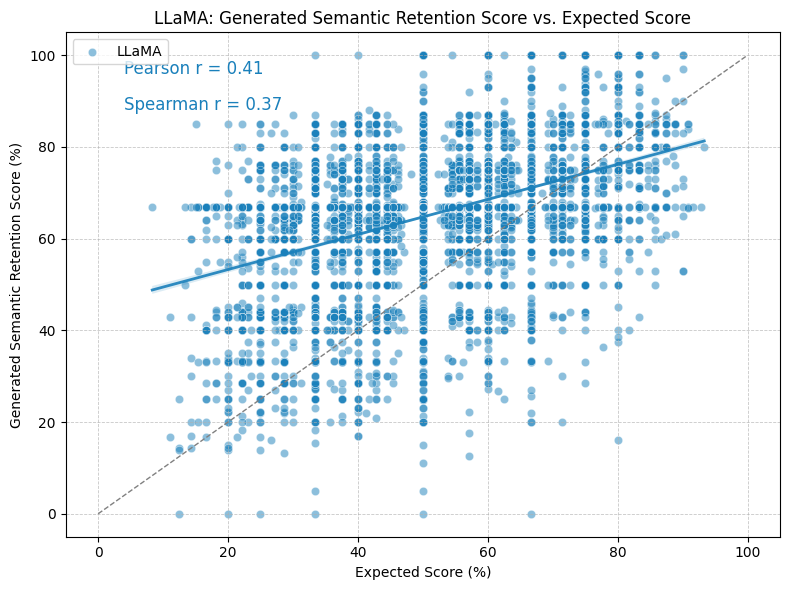

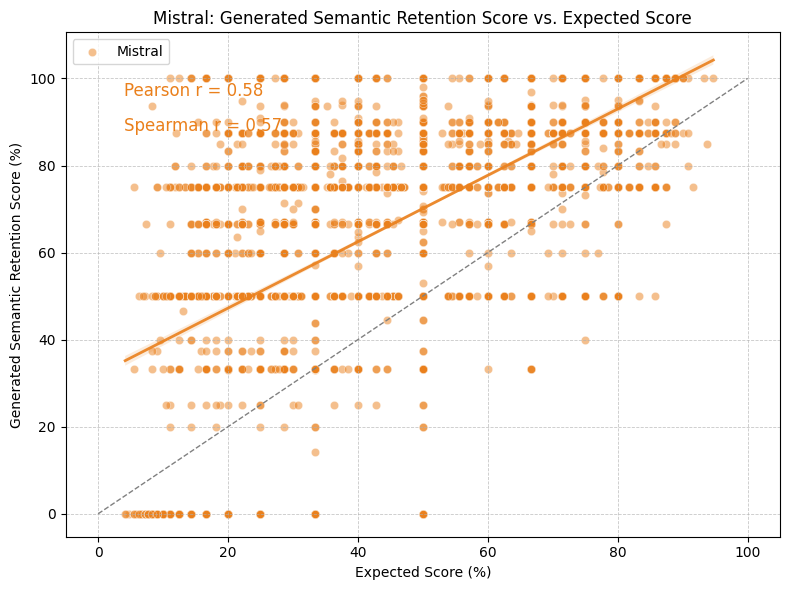

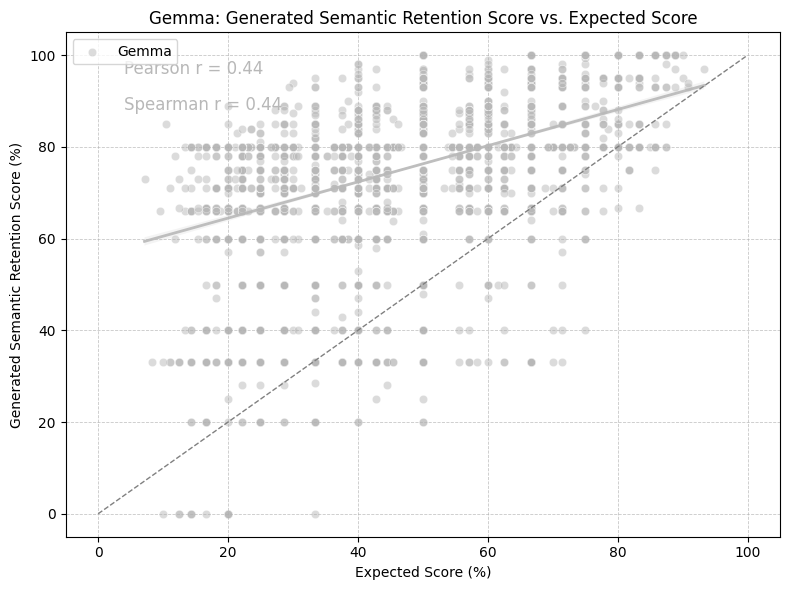

LLaMA → Valid: 9796, Outliers: 460, Pearson r: 0.41, Spearman r: 0.37
Mistral → Valid: 9968, Outliers: 432, Pearson r: 0.58, Spearman r: 0.57
Gemma → Valid: 9873, Outliers: 764, Pearson r: 0.44, Spearman r: 0.44


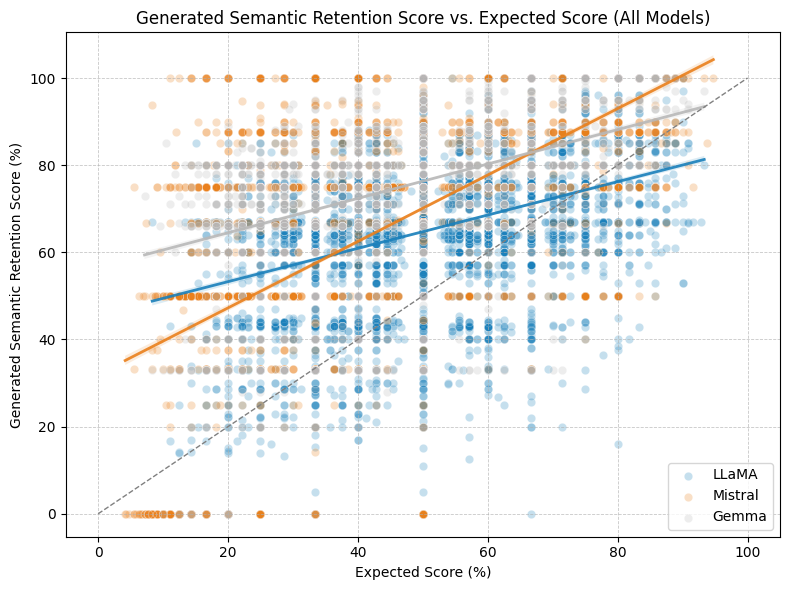

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr


model_colors = {
    "LLaMA":  "#1a80bb",   # blue
    "Mistral":"#ea801c",   # orange
    "Gemma":  "#b8b8b8"    # gray
}

model_info = {
    "LLaMA":  {"score": "llama_score",  "retained": "llama_retained",  "lost": "llama_lost"},
    "Mistral":{"score": "mistral_score","retained": "mistral_retained","lost": "mistral_lost"},
    "Gemma":  {"score": "gemma_score",  "retained": "gemma_retained",  "lost": "gemma_lost"}
}

def count_facts(fact_string):
    if pd.isna(fact_string):
        return 0
    s = str(fact_string).strip()
    if s == "":
        return 0
    return len([f.strip() for f in s.split(",") if f.strip() != ""])

def compute_expected_score(retained, lost):
    total = retained + lost
    return (retained / total * 100.0) if total > 0 else None

def iqr_outlier_count(series: pd.Series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())


def plot_score_vs_expected_clean(df, model_name, score_col, retained_col, lost_col, save=True):
    # Number of retained/lost facts
    df[f"{model_name}_retained_count"] = df[retained_col].apply(count_facts)
    df[f"{model_name}_lost_count"] = df[lost_col].apply(count_facts)

    # Expected Score (0~100)
    df[f"{model_name}_expected_score"] = df.apply(
        lambda r: compute_expected_score(
            r[f"{model_name}_retained_count"],
            r[f"{model_name}_lost_count"]
        ), axis=1
    )

    # Generated Score (0~100)
    df[score_col] = pd.to_numeric(df[score_col].astype(str).str.replace("%", "", regex=False), errors="coerce")
    df[f"{model_name}_expected_score"] = pd.to_numeric(df[f"{model_name}_expected_score"], errors="coerce")

    # Valid rows only
    df_valid = df[
        df[score_col].notna() &
        df[f"{model_name}_expected_score"].notna() &
        df[score_col].between(0, 100) &
        df[f"{model_name}_expected_score"].between(0, 100)
    ].copy()

    valid_count = len(df_valid)
    if valid_count == 0:
        print(f"[{model_name}] No valid rows after filtering.")
        return {"valid_count": 0, "outlier_count": 0, "pearson_r": float("nan"), "spearman_r": float("nan")}

    outlier_count = iqr_outlier_count(df_valid[score_col])

    pearson_r, _ = pearsonr(df_valid[f"{model_name}_expected_score"], df_valid[score_col])
    spearman_r, _ = spearmanr(df_valid[f"{model_name}_expected_score"], df_valid[score_col])

    # Plot
    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        x=f"{model_name}_expected_score",
        y=score_col,
        data=df_valid,
        alpha=0.5,
        color=model_colors[model_name],
        label=model_name
    )

    sns.regplot(
        x=f"{model_name}_expected_score",
        y=score_col,
        data=df_valid,
        scatter=False,
        color=model_colors[model_name],
        line_kws={"linewidth": 2, "alpha": 0.9}
    )
    # y=x line
    plt.plot([0, 100], [0, 100], linestyle="--", color="gray", linewidth=1)

    plt.text(4, 96, f'Pearson r = {pearson_r:.2f}', fontsize=12, color=model_colors[model_name])
    plt.text(4, 88, f'Spearman r = {spearman_r:.2f}', fontsize=12, color=model_colors[model_name])

    plt.xlabel("Expected Score (%)")
    plt.ylabel("Generated Semantic Retention Score (%)")
    plt.title(f"{model_name}: Generated Semantic Retention Score vs. Expected Score")
    plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
    plt.tight_layout()
    if save:
        plt.savefig(f"{model_name.lower()}_generated_vs_expected.png", dpi=300, bbox_inches="tight", transparent=True)
    plt.show()

    return {
        "valid_count": valid_count,
        "outlier_count": outlier_count,
        "pearson_r": pearson_r,
        "spearman_r": spearman_r
    }

def plot_combined_generated_vs_expected(df, save=True):
    plt.figure(figsize=(8, 6))

    for model_name, cols in model_info.items():
        tmp = df.copy()
        tmp[f"{model_name}_retained_count"] = tmp[cols["retained"]].apply(count_facts)
        tmp[f"{model_name}_lost_count"] = tmp[cols["lost"]].apply(count_facts)
        tmp[f"{model_name}_expected_score"] = tmp.apply(
            lambda r: compute_expected_score(
                r[f"{model_name}_retained_count"],
                r[f"{model_name}_lost_count"]
            ), axis=1
        )
        tmp[cols["score"]] = pd.to_numeric(tmp[cols["score"]].astype(str).str.replace("%", "", regex=False), errors="coerce")
        tmp = tmp[
            tmp[cols["score"]].notna() &
            tmp[f"{model_name}_expected_score"].notna() &
            tmp[cols["score"]].between(0, 100) &
            tmp[f"{model_name}_expected_score"].between(0, 100)
        ].copy()

        if len(tmp) == 0:
            continue

        sns.scatterplot(
            x=f"{model_name}_expected_score",
            y=cols["score"],
            data=tmp,
            alpha=0.25, 
            color=model_colors[model_name],
            label=model_name
        )
        sns.regplot(
            x=f"{model_name}_expected_score",
            y=cols["score"],
            data=tmp,
            scatter=False,
            color=model_colors[model_name],
            line_kws={"linewidth": 2, "alpha": 0.9}
        )

    plt.plot([0, 100], [0, 100], linestyle="--", color="gray", linewidth=1, label="y = x")

    plt.xlabel("Expected Score (%)")
    plt.ylabel("Generated Semantic Retention Score (%)")
    plt.title("Generated Semantic Retention Score vs. Expected Score (All Models)")
    plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
    plt.tight_layout()
    if save:
        plt.savefig("combined_generated_vs_expected.png", dpi=300, bbox_inches="tight", transparent=True)
    plt.show()

if __name__ == "__main__":
    df = pd.read_csv("final_dataset.csv")

    results = {}
    for model, cols in model_info.items():
        res = plot_score_vs_expected_clean(df.copy(), model, cols["score"], cols["retained"], cols["lost"])
        results[model] = res

    for model, res in results.items():
        print(
            f"{model} → Valid: {res['valid_count']}, "
            f"Outliers: {res['outlier_count']}, "
            f"Pearson r: {res['pearson_r']:.2f}, "
            f"Spearman r: {res['spearman_r']:.2f}"
        )

    plot_combined_generated_vs_expected(df.copy(), save=True)

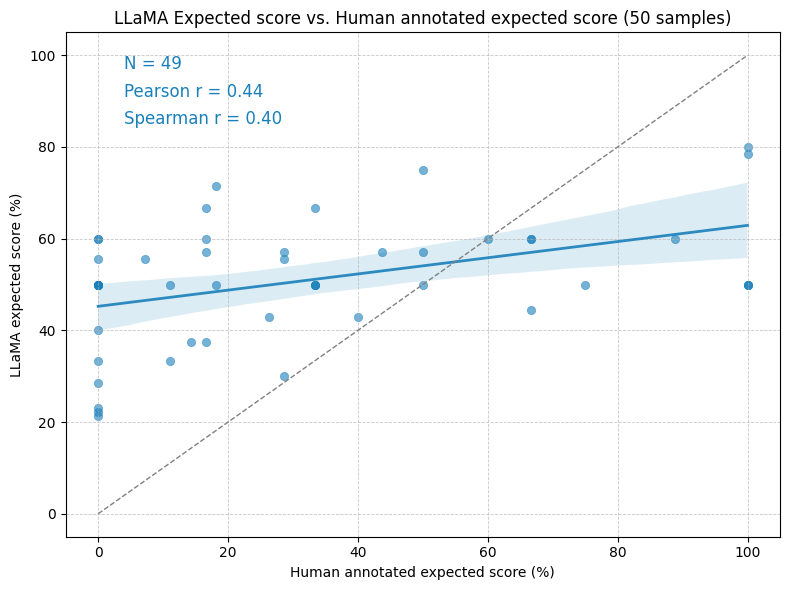

LLaMA vs Human → Pearson r: 0.436, Spearman r: 0.403, N=49, Outliers(by IQR on model exp.): 0


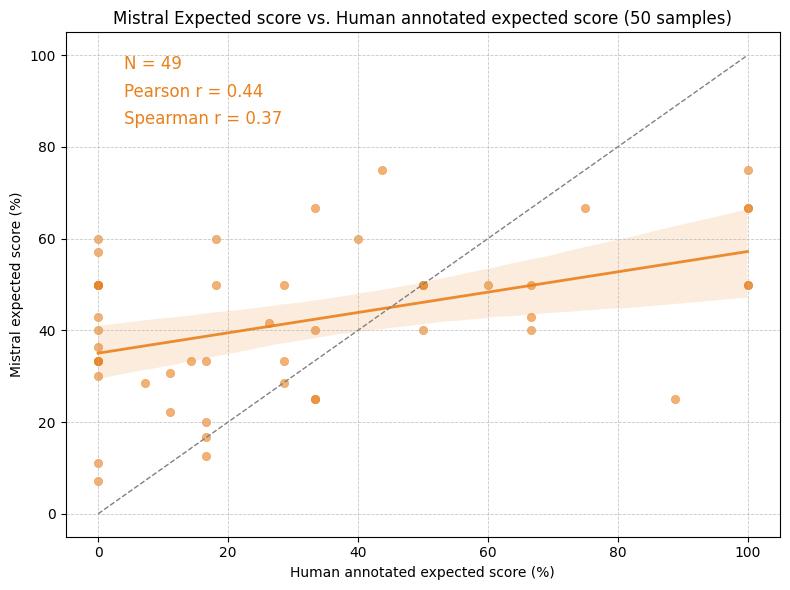

Mistral vs Human → Pearson r: 0.443, Spearman r: 0.374, N=49, Outliers(by IQR on model exp.): 0


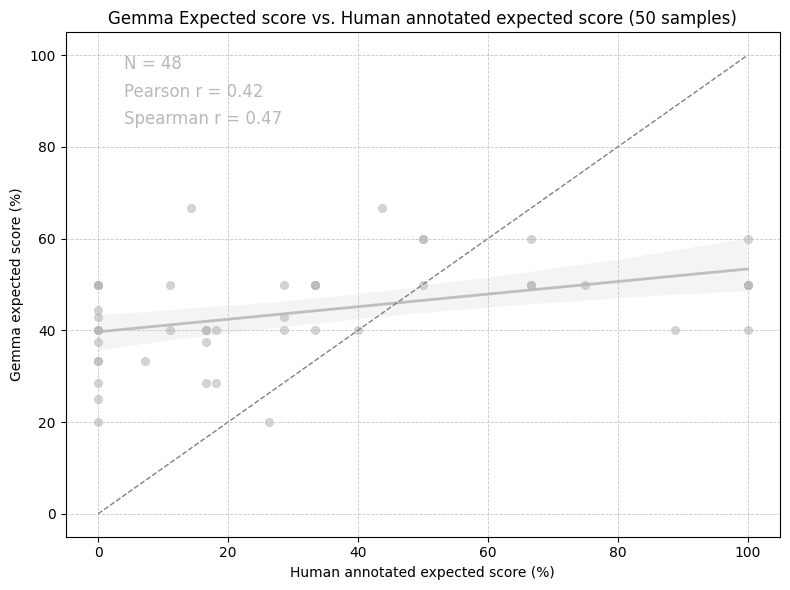

Gemma vs Human → Pearson r: 0.420, Spearman r: 0.472, N=48, Outliers(by IQR on model exp.): 4
LLaMA → Valid: 49, Outliers: 0, Pearson r: 0.44, Spearman r: 0.40
Mistral → Valid: 49, Outliers: 0, Pearson r: 0.44, Spearman r: 0.37
Gemma → Valid: 48, Outliers: 4, Pearson r: 0.42, Spearman r: 0.47


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr


INPUT_CSV = "human_validation_final_50samples.csv"  

model_colors = {
    "LLaMA":  "#1a80bb",   # blue
    "Mistral":"#ea801c",   # orange
    "Gemma":  "#b8b8b8"    # gray
}

model_info = {
    "LLaMA":  {"retained": "llama_retained",  "lost": "llama_lost"},
    "Mistral":{"retained": "mistral_retained","lost": "mistral_lost"},
    "Gemma":  {"retained": "gemma_retained",  "lost": "gemma_lost"}
}


HUMAN_RETAINED_COUNT_COL = "Human annotated Retained List"
HUMAN_LOST_COUNT_COL     = "Human annotated Lost List"


def count_facts(fact_string):
    if pd.isna(fact_string):
        return 0
    s = str(fact_string).strip()
    if s == "":
        return 0
    return len([f.strip() for f in s.split(",") if f.strip() != ""])

def compute_expected_score(retained_count, lost_count):
    total = retained_count + lost_count
    return (retained_count / total * 100.0) if total > 0 else np.nan

def iqr_outlier_count(series: pd.Series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())

def add_human_expected_score(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # 숫자 보장
    df[HUMAN_RETAINED_COUNT_COL] = pd.to_numeric(df[HUMAN_RETAINED_COUNT_COL], errors="coerce")
    df[HUMAN_LOST_COUNT_COL]     = pd.to_numeric(df[HUMAN_LOST_COUNT_COL], errors="coerce")

    df["human_expected_score"] = df.apply(
        lambda r: compute_expected_score(r[HUMAN_RETAINED_COUNT_COL], r[HUMAN_LOST_COUNT_COL]), axis=1
    )
    return df

def add_model_expected_scores(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for model_name, cols in model_info.items():
        rcol, lcol = cols["retained"], cols["lost"]
        df[f"{model_name}_retained_count"] = df[rcol].apply(count_facts)
        df[f"{model_name}_lost_count"]     = df[lcol].apply(count_facts)
        df[f"{model_name}_expected_score"] = df.apply(
            lambda r: compute_expected_score(r[f"{model_name}_retained_count"], r[f"{model_name}_lost_count"]), axis=1
        )
    return df

def plot_model_expected_vs_human(df: pd.DataFrame, model_name: str, save=True):
    df = df.copy()

    xcol = "human_expected_score"
    ycol = f"{model_name}_expected_score"

    df[xcol] = pd.to_numeric(df[xcol], errors="coerce")
    df[ycol] = pd.to_numeric(df[ycol], errors="coerce")

    temp = df[[xcol, ycol]].dropna()
    temp = temp[temp[xcol].between(0, 100) & temp[ycol].between(0, 100)]

    n = len(temp)
    if n == 0:
        print(f"[{model_name}] No valid rows after filtering.")
        return {"valid_count": 0, "outlier_count": 0, "pearson_r": np.nan, "spearman_r": np.nan}

    outliers = iqr_outlier_count(temp[ycol])
    pearson_r, _ = pearsonr(temp[xcol], temp[ycol])
    spearman_r, _ = spearmanr(temp[xcol], temp[ycol])

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=xcol, y=ycol, data=temp,
        color=model_colors[model_name], alpha=0.6, edgecolor=None
    )
    sns.regplot(
        x=xcol, y=ycol, data=temp,
        scatter=False, color=model_colors[model_name],
        line_kws={"linewidth": 2, "alpha": 0.9}
    )
    plt.plot([0, 100], [0, 100], linestyle="--", color="gray", linewidth=1)

    plt.title(f"{model_name} Expected score vs. Human annotated expected score (50 samples)")
    plt.xlabel("Human annotated expected score (%)")
    plt.ylabel(f"{model_name} expected score (%)")

    plt.text(4, 100, f"N = {n}", fontsize=12, color=model_colors[model_name], va="top")
    plt.text(4, 94, f"Pearson r = {pearson_r:.2f}", fontsize=12, color=model_colors[model_name], va="top")
    plt.text(4, 88, f"Spearman r = {spearman_r:.2f}", fontsize=12, color=model_colors[model_name], va="top")

    plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
    plt.tight_layout()
    if save:
        plt.savefig(f"{model_name.lower()}_expected_vs_human_expected.png", dpi=300, bbox_inches="tight", transparent=True)
    plt.show()

    print(f"{model_name} vs Human → Pearson r: {pearson_r:.3f}, Spearman r: {spearman_r:.3f}, N={n}, Outliers(by IQR on model exp.): {outliers}")
    return {"valid_count": n, "outlier_count": outliers, "pearson_r": pearson_r, "spearman_r": spearman_r}



if __name__ == "__main__":
    df = pd.read_csv(INPUT_CSV)
    df = add_human_expected_score(df)
    df = add_model_expected_scores(df)

    results = {}
    for model in model_info.keys():
        res = plot_model_expected_vs_human(df, model, save=True)
        results[model] = res

    for model, res in results.items():
        print(
            f"{model} → Valid: {res['valid_count']}, "
            f"Outliers: {res['outlier_count']}, "
            f"Pearson r: {res['pearson_r']:.2f}, "
            f"Spearman r: {res['spearman_r']:.2f}"
        )

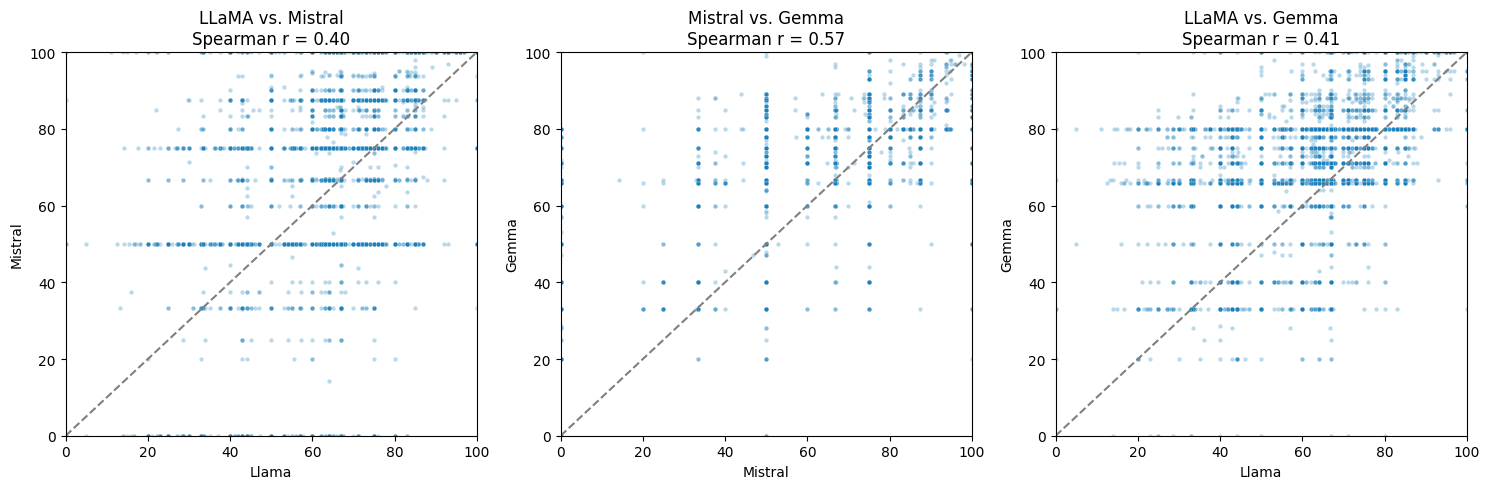

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

df = pd.read_csv("final_dataset.csv")

mask = (
    df["llama_score"].between(0,100) &
    df["mistral_score"].between(0,100) &
    df["gemma_score"].between(0,100)
)
df_valid = df[mask].copy()


pairs = [
    ("llama_score", "mistral_score", "LLaMA vs. Mistral"),
    ("mistral_score", "gemma_score", "Mistral vs. Gemma"),
    ("llama_score", "gemma_score", "LLaMA vs. Gemma")
]

plt.figure(figsize=(15, 5))

for i, (c1, c2, title) in enumerate(pairs, 1):
    rho, _ = spearmanr(df_valid[c1], df_valid[c2])

    plt.subplot(1, 3, i)
    sns.scatterplot(
        x=df_valid[c1], y=df_valid[c2],
        alpha=0.3, s=10, color="#1a80bb"
    )
    plt.plot([0, 100], [0, 100], ls="--", c="gray")  # y=x 기준선
    plt.title(f"{title}\nSpearman r = {rho:.2f}")
    plt.xlabel(c1.replace("_score", "").capitalize())
    plt.ylabel(c2.replace("_score", "").capitalize())
    plt.xlim(0, 100)
    plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## Appendix Figures

The figures in this section were generated using the dataset df_ores_topics_deduplicated.csv. These figures illustrate the distribution of fine-grained topics as predicted by the ORES model.

Specifically, the figure shows the distribution of the top 15 fine-grained topics at the time of the midterm analysis. Importantly, since each article title can be assigned to multiple topics simultaneously, the counts represent the aggregated topic assignments across all articles, rather than mutually exclusive categories.

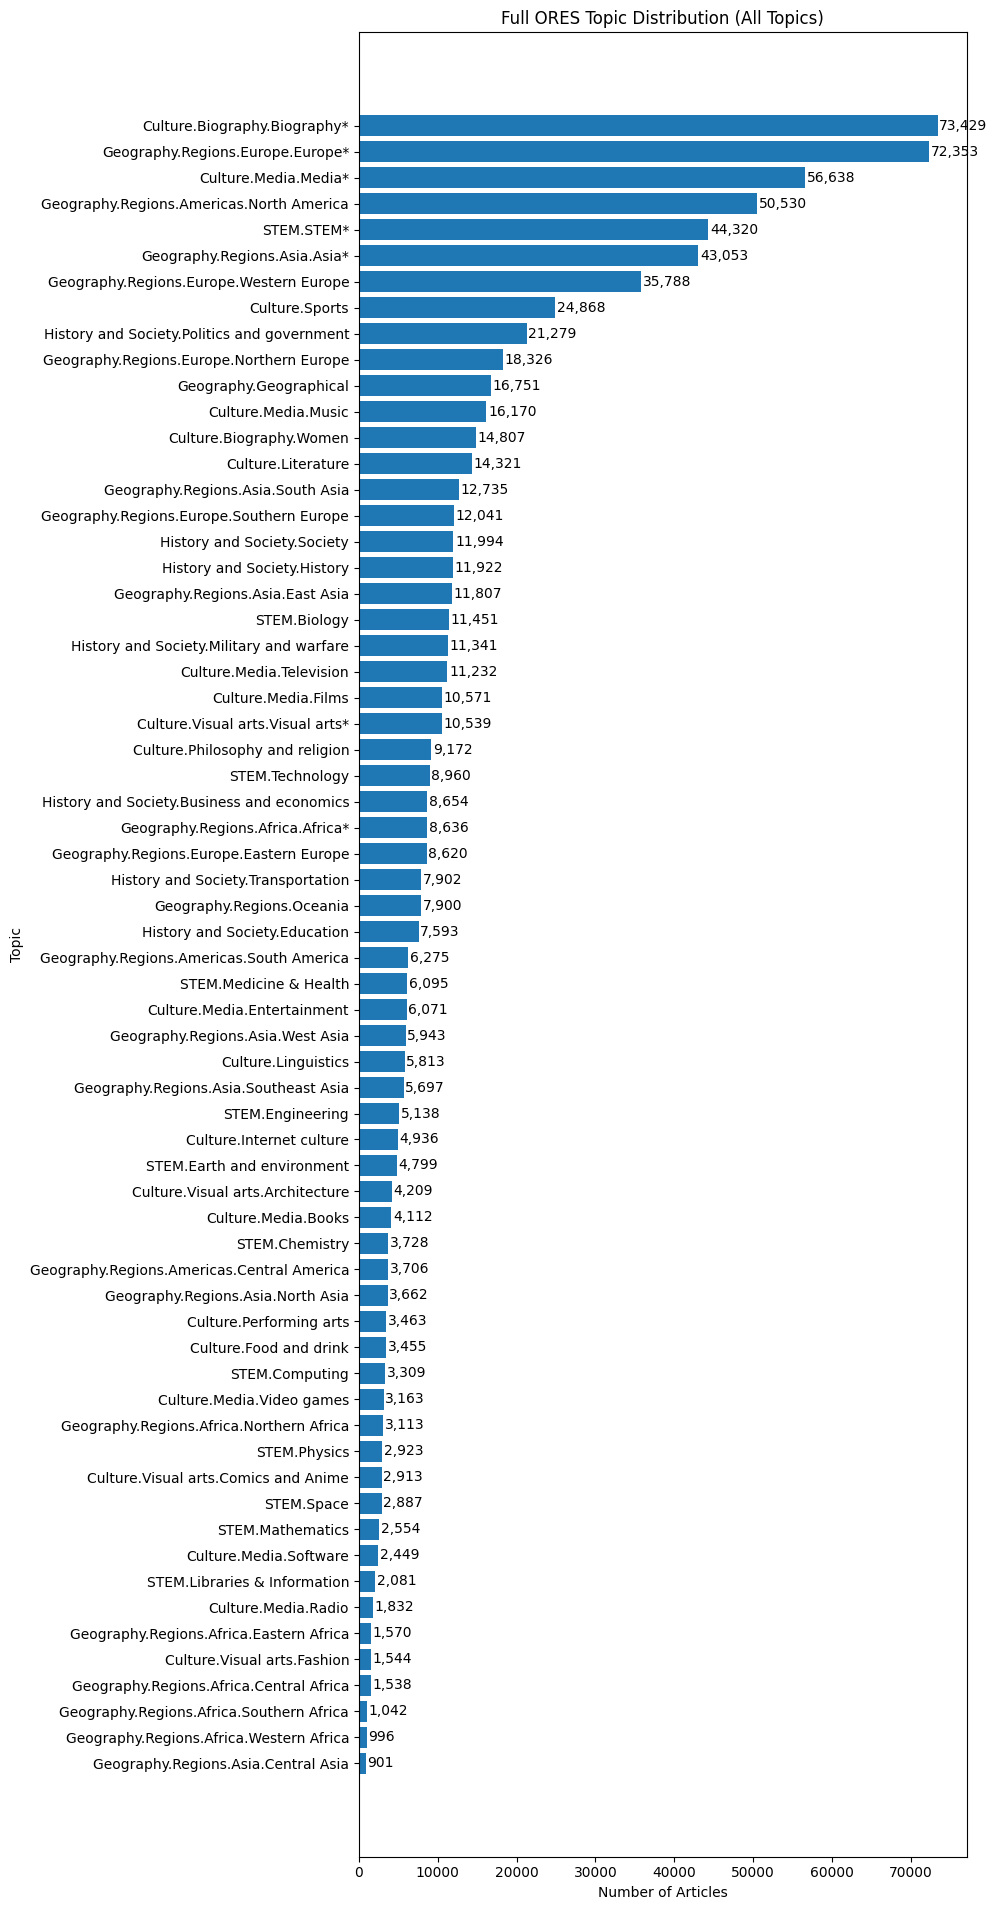

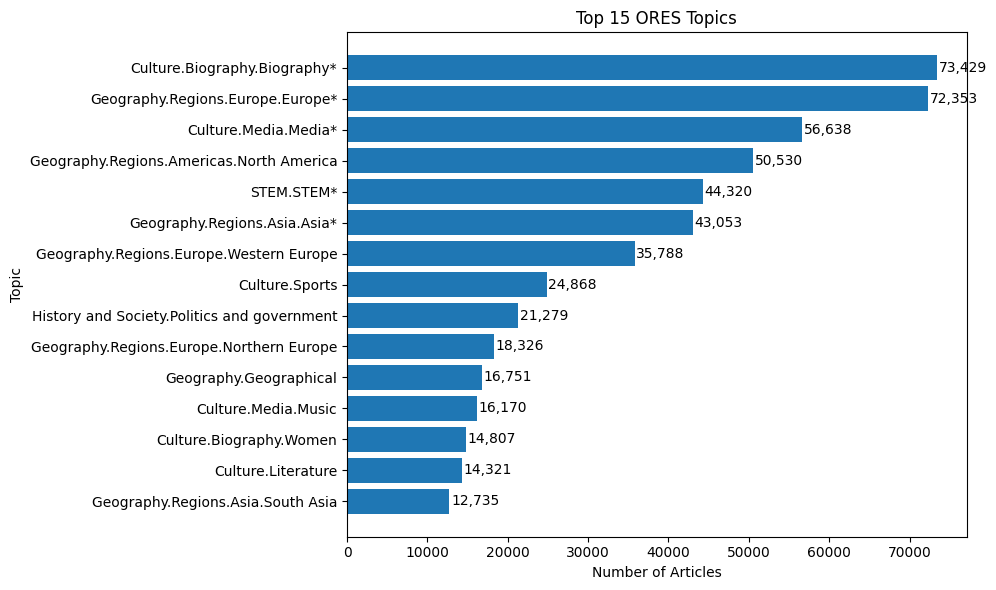

In [7]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import ast
from collections import Counter

# 데이터 로드
df_clean = pd.read_csv("df_ores_topics_deduplicated.csv")
df_clean["ores_topics"] = df_clean["ores_topics"].apply(ast.literal_eval)

# 모든 주제 펼쳐서 세기
all_topics = [topic for sublist in df_clean["ores_topics"] for topic in sublist]
topic_counts = Counter(all_topics)
sorted_topics = topic_counts.most_common()
labels, values = zip(*sorted_topics)

### Full Distribution
plt.figure(figsize=(10, len(labels) * 0.3))
bars = plt.barh(labels[::-1], values[::-1])
plt.title("Full ORES Topic Distribution (All Topics)")
plt.xlabel("Number of Articles")
plt.ylabel("Topic")
for bar, value in zip(bars, values[::-1]):
    plt.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f"{value:,}", va='center')
plt.tight_layout()
plt.show()

### Top 15 Only
top_15 = sorted_topics[:15]
labels_15, values_15 = zip(*top_15)

plt.figure(figsize=(10, 6))
bars = plt.barh(labels_15[::-1], values_15[::-1])
plt.title("Top 15 ORES Topics")
plt.xlabel("Number of Articles")
plt.ylabel("Topic")
for bar, value in zip(bars, values_15[::-1]):
    plt.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f"{value:,}", va='center')
plt.tight_layout()
plt.show()


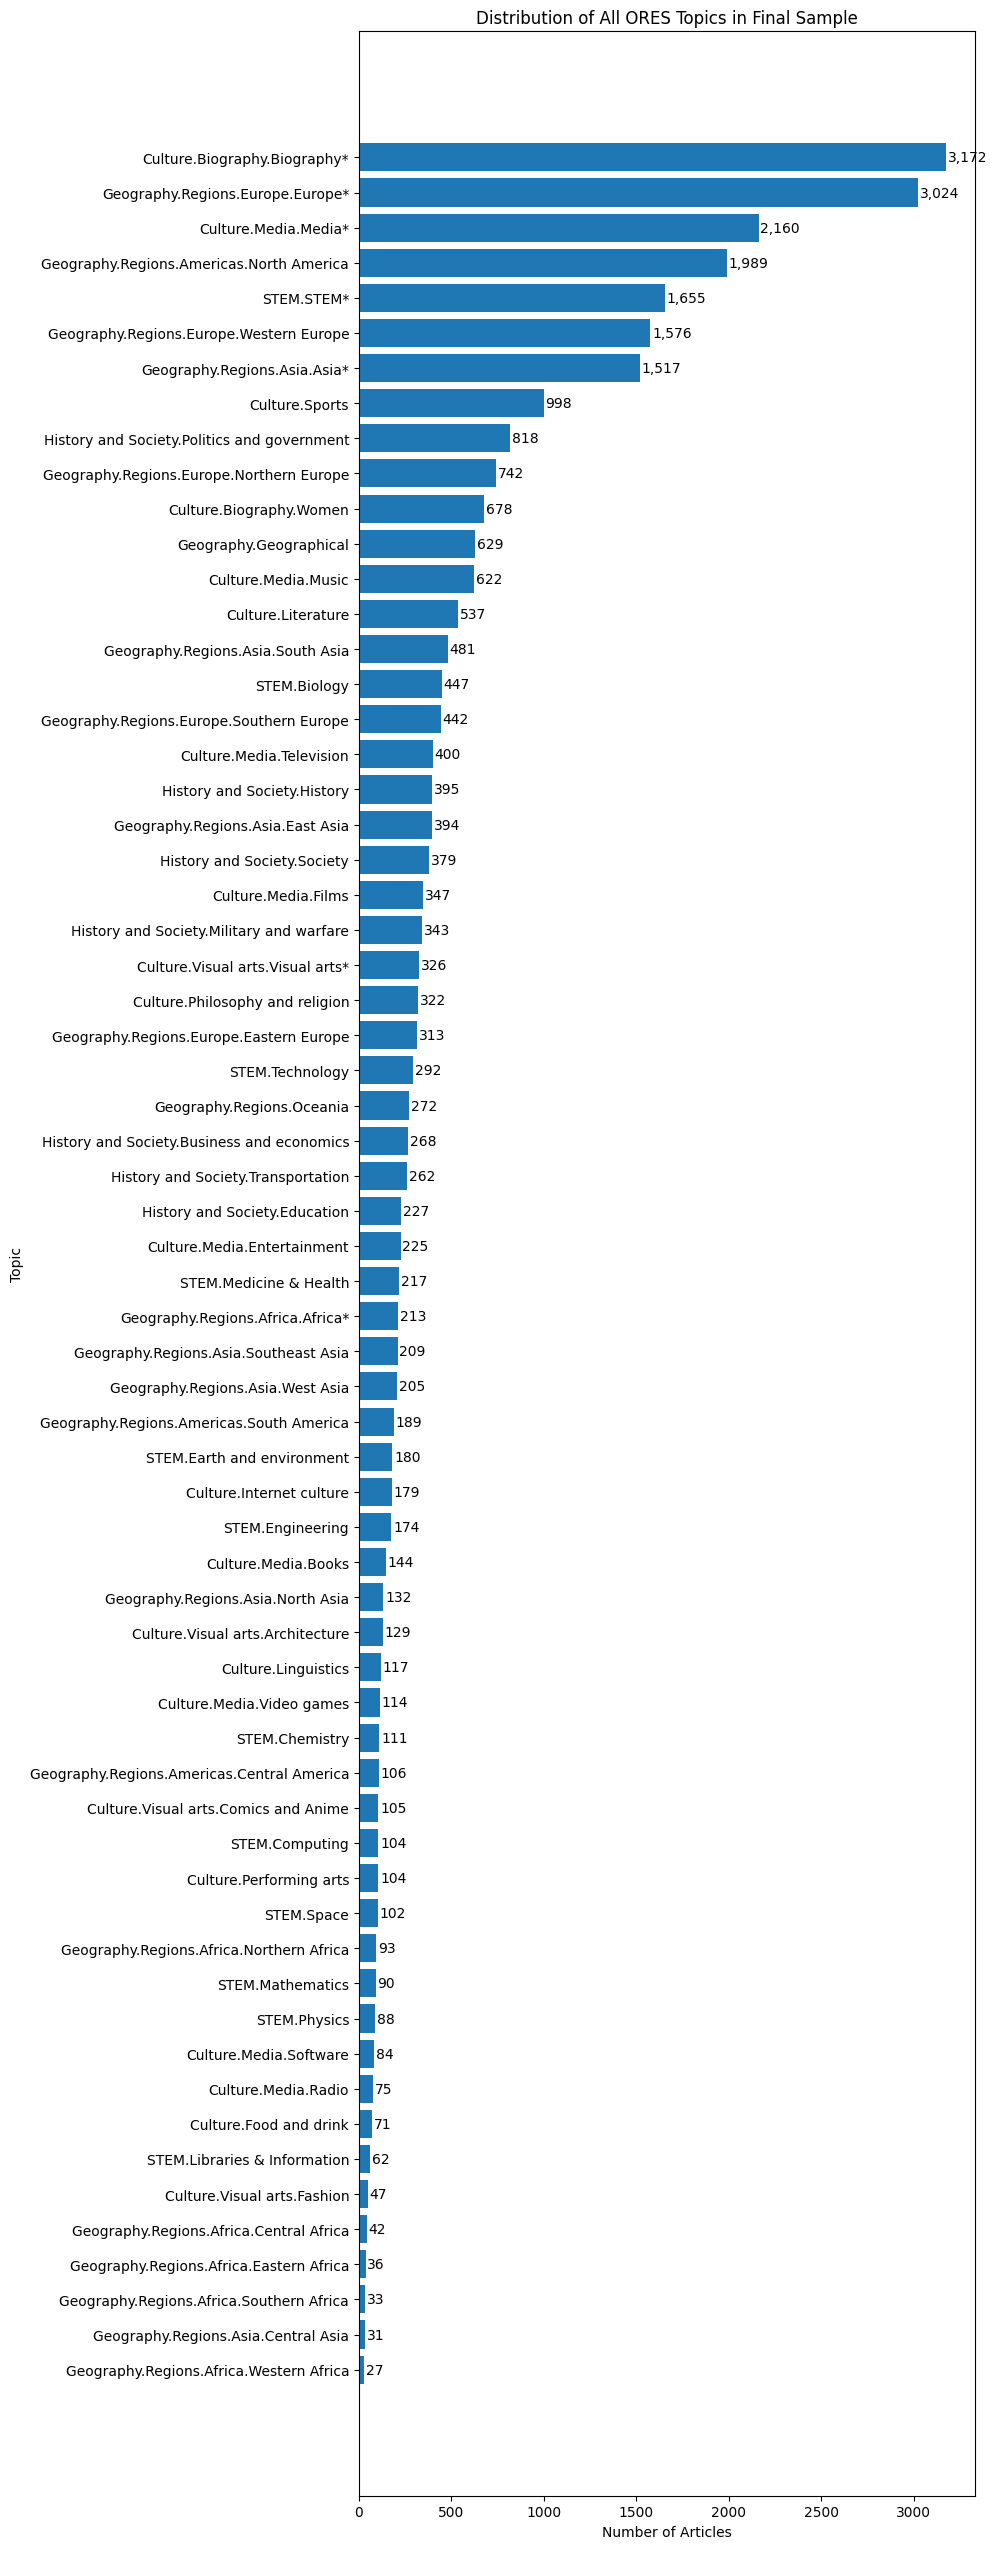

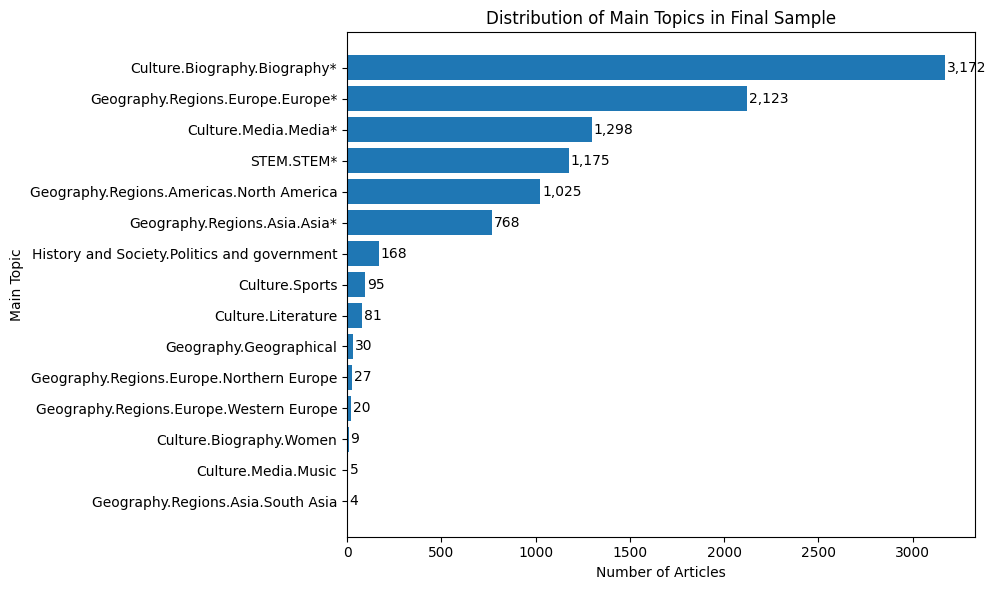

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from collections import Counter

# 파일 로드
df_final = pd.read_csv("final_dataset.csv")

# 🔹 ores_topics 분포 시각화 (Multi-label 기반)
df_final["ores_topics"] = df_final["ores_topics"].apply(ast.literal_eval)
all_topics = [topic for sublist in df_final["ores_topics"] for topic in sublist]
topic_counts = Counter(all_topics)
sorted_topics = topic_counts.most_common()
labels, values = zip(*sorted_topics)

plt.figure(figsize=(10, len(labels) * 0.4))
bars = plt.barh(labels[::-1], values[::-1])
plt.title("Distribution of All ORES Topics in Final Sample")
plt.xlabel("Number of Articles")
plt.ylabel("Topic")

for bar, value in zip(bars, values[::-1]):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
             f"{value:,}", va='center')

plt.tight_layout()
plt.show()

# 🔹 main_topic 분포 시각화 (Single-label 기반)
main_topic_counts = df_final["main_topic"].value_counts()
labels_main = main_topic_counts.index.tolist()
values_main = main_topic_counts.values.tolist()

plt.figure(figsize=(10, 6))
bars = plt.barh(labels_main[::-1], values_main[::-1])
plt.title("Distribution of Main Topics in Final Sample")
plt.xlabel("Number of Articles")
plt.ylabel("Main Topic")

for bar, value in zip(bars, values_main[::-1]):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
             f"{value:,}", va='center')

plt.tight_layout()
plt.show()